**1) Setup and Imports**

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow # For displaying frames in Colab

# Set your video paths
INPUT_VIDEO = 'Video1.mp4'
OUTPUT_VIDEO = 'stabilized_video.mp4'

**2) Motion Estimation (Lucas-Kanade & Affine Transform)**

In [17]:
cap = cv2.VideoCapture(INPUT_VIDEO)
n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)

# Store the transformations (dx, dy, da)
transforms = np.zeros((n_frames-1, 3), np.float32)

_, prev = cap.read()
prev_gray = cv2.cvtColor(prev, cv2.COLOR_BGR2GRAY)

for i in range(n_frames-2):
    # Find good features to track in the previous frame
    prev_pts = cv2.goodFeaturesToTrack(prev_gray, maxCorners=200, qualityLevel=0.01, minDistance=30, blockSize=3)

    success, curr = cap.read()
    if not success: break
    curr_gray = cv2.cvtColor(curr, cv2.COLOR_BGR2GRAY)

    # Track points using Lucas-Kanade
    curr_pts, status, err = cv2.calcOpticalFlowPyrLK(prev_gray, curr_gray, prev_pts, None)

    # Filter only valid points
    idx = np.where(status==1)[0]
    prev_pts = prev_pts[idx]
    curr_pts = curr_pts[idx]

    # Estimate the rigid transformation (translation + rotation)
    m, inliers = cv2.estimateAffinePartial2D(prev_pts, curr_pts)

    # Extract translation and rotation angle
    dx = m[0, 2]
    dy = m[1, 2]
    da = np.arctan2(m[1, 0], m[0, 0])

    transforms[i] = [dx, dy, da]
    prev_gray = curr_gray

cap.release()

# Calculate the absolute trajectory by accumulating transformations
trajectory = np.cumsum(transforms, axis=0)

**3) Trajectory Smoothing**

In [18]:
SMOOTHING_RADIUS = 30 # Adjust this: higher means smoother, but more cropping needed

def moving_average(curve, radius):
    window_size = 2 * radius + 1
    f = np.ones(window_size)/window_size
    curve_pad = np.pad(curve, (radius, radius), 'edge')
    curve_smoothed = np.convolve(curve_pad, f, mode='same')
    curve_smoothed = curve_smoothed[radius:-radius]
    return curve_smoothed

def smooth_trajectory(trajectory, radius):
    smoothed_trajectory = np.copy(trajectory)
    for i in range(3):
        smoothed_trajectory[:,i] = moving_average(trajectory[:,i], radius)
    return smoothed_trajectory

smoothed_trajectory = smooth_trajectory(trajectory, SMOOTHING_RADIUS)

# Calculate the difference between smoothed and original trajectory
difference = smoothed_trajectory - trajectory

# Calculate newer, smoother transformations
transforms_smooth = transforms + difference

**4) Motion Compensation (Warping) and Video Output**

In [19]:
cap = cv2.VideoCapture(INPUT_VIDEO)
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(OUTPUT_VIDEO, fourcc, fps, (w, h))

# Fix border artifacts by scaling up slightly
ZOOM_FACTOR = 1.05

def fix_border(frame):
    s = frame.shape
    T = cv2.getRotationMatrix2D((s[1]/2, s[0]/2), 0, ZOOM_FACTOR)
    return cv2.warpAffine(frame, T, (s[1], s[0]))

cap.set(cv2.CAP_PROP_POS_FRAMES, 0) # Reset to first frame
_, prev = cap.read()
out.write(prev) # Write first frame

for i in range(n_frames-2):
    success, frame = cap.read()
    if not success: break

    # Reconstruct transformation matrix
    dx = transforms_smooth[i,0]
    dy = transforms_smooth[i,1]
    da = transforms_smooth[i,2]

    m = np.zeros((2,3), np.float32)
    m[0,0] = np.cos(da)
    m[0,1] = -np.sin(da)
    m[1,0] = np.sin(da)
    m[1,1] = np.cos(da)
    m[0,2] = dx
    m[1,2] = dy

    # Apply affine warping
    frame_stabilized = cv2.warpAffine(frame, m, (w,h))
    frame_stabilized = fix_border(frame_stabilized)

    out.write(frame_stabilized)

cap.release()
out.release()
print("Stabilization complete. Download:", OUTPUT_VIDEO)

Stabilization complete. Download: stabilized_video.mp4


**5) Visualizing the Error Analysis**

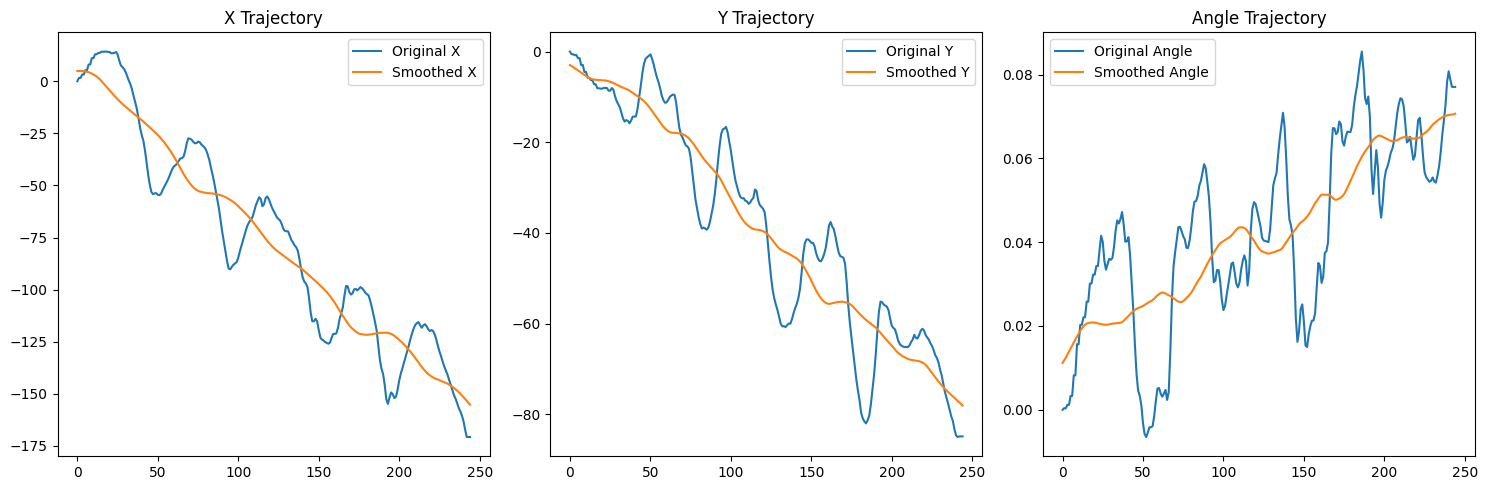

In [20]:
plt.figure(figsize=(15, 5))

# Plot X trajectory
plt.subplot(1, 3, 1)
plt.plot(trajectory[:, 0], label='Original X')
plt.plot(smoothed_trajectory[:, 0], label='Smoothed X')
plt.title("X Trajectory")
plt.legend()

# Plot Y trajectory
plt.subplot(1, 3, 2)
plt.plot(trajectory[:, 1], label='Original Y')
plt.plot(smoothed_trajectory[:, 1], label='Smoothed Y')
plt.title("Y Trajectory")
plt.legend()

# Plot Angle trajectory
plt.subplot(1, 3, 3)
plt.plot(trajectory[:, 2], label='Original Angle')
plt.plot(smoothed_trajectory[:, 2], label='Smoothed Angle')
plt.title("Angle Trajectory")
plt.legend()

plt.tight_layout()
plt.show()